<a href="https://colab.research.google.com/github/omzeybek/Yeditepe_Data_Science_DATS501/blob/main/Week_13_Light_GBM_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Light GBM - Boosting Algorithm

LightGBM is an open-source, fast, and efficient gradient boosting framework developed by Microsoft. It’s widely used for machine learning tasks such as classification, regression, and ranking. It is designed to be distributed and efficient with the following main goals: speed, scalability, and high performance.

In this example, we will employ the light GBM algorithm to estimate median house prices in California and classify whether cancer tumours are benign or malignant.  Our sample datasets are relatively smaller ones, in fact Light GBM algorithm should be employed on larger datasets to increase performance. But Today, we aim to give you a perspective on how this algorithm works.



First as always we do, we start with importing the neccesary packages.

In [ ]:
from lightgbm import LGBMRegressor #Light GBM algorithm
import lightgbm as lgb

from sklearn.datasets import fetch_california_housing #fetching our regression dataset
from sklearn.model_selection import train_test_split, GridSearchCV # train-test split formation
from sklearn.metrics import mean_squared_error, mean_absolute_error #loss function to assess if we had a proper model.
import shap #for model interpretation
import matplotlib.pyplot as plt



Also we can add GridSearch and Shap packages for extra controls on the existence of the overfitting problem and model interpretability

In [ ]:
X, y = fetch_california_housing(return_X_y=True,as_frame=True)
feature_names = fetch_california_housing().feature_names

Let's explore our data set

In [ ]:
print(feature_names)

Infromation on the California housing dataset, which is extracted from scikit-learn package documentation

In [ ]:
print(fetch_california_housing().DESCR)

Now it's time for some data understanding. We will report descriptive statistics of our dataset

In [ ]:
X.describe()

In [ ]:
y.describe()

As you can remember, we have done a detailed assessment of descriptive statistics of variable in one of our previous classes. So this time we will skip the introduction of statistics.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Next before implementing GridSearch Cross-validation to orchestrate our hyperparameter tuning phase, we need to input parameter values that will be tested during the search.

In [ ]:
param_grid = {
    'num_leaves': [31, 50],
    'learning_rate': [0.1, 0.05],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

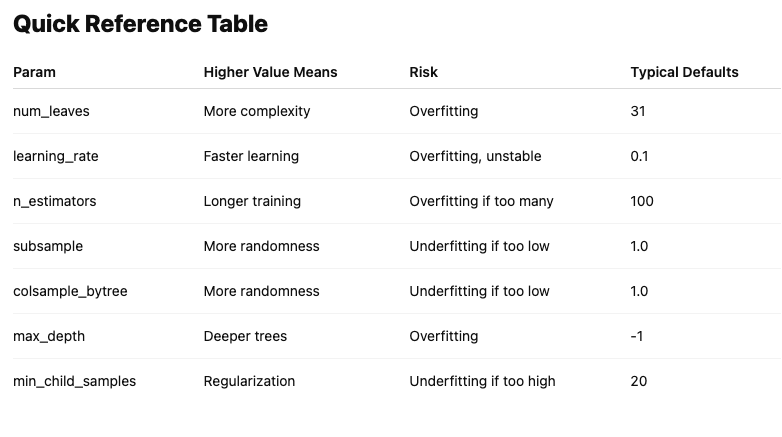

In [ ]:
#forming the regressor.

In [ ]:
lgbm = LGBMRegressor(random_state=42)


Grid Search for locating. the best model

In [ ]:
grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='neg_root_mean_squared_error',  # RMSE (the negative because GridSearchCV maximizes)
    n_jobs=-1,
    verbose=1
)

Now we will fit the best model that is given as output by the gridsearch algorithm.

In [ ]:
grid

In [ ]:
grid.fit(X_train, y_train)

Give information on the best hyperparameters  

In [ ]:
# Best model/params
print("Best hyperparameters:", grid.best_params_)
print("Best CV RMSE (negative):", grid.best_score_)



In [ ]:
# Evaluate on test set
y_pred = grid.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

Now interpret the effects of variables to estimation. We will write an explainer procedure for our model.  

In [ ]:
# 7. SHAP for interpretation
explainer = shap.Explainer(grid.best_estimator_, X_train)
shap_values = explainer(X_test,check_additivity=False)

# Summary plot: global feature importance
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=True)

# Optional: Waterfall plot for a specific prediction
idx = 0
shap.plots.waterfall(shap_values[idx], max_display=10)
plt.show()

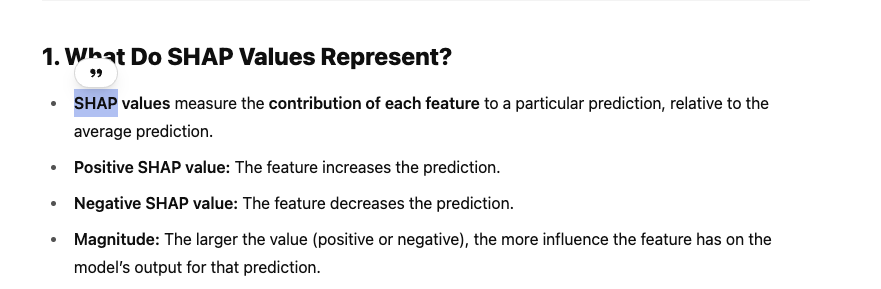

#A Classfication Example  (with comments)

Main differences between classification example and the regression one are;

- Use LGBMClassifier instead of LGBMRegressor.

- Change the scoring parameter in GridSearchCV to a classification metric (e.g., 'accuracy').

- Use appropriate classification metrics for evaluation.

of course our dataset should also be transformed to a dataset with binary Target Variable. Below, We will use the California Housing dataset and turn the regression target into a binary classification problem (e.g., "above median" = 1, "below median" = 0).

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Load data as DataFrame
raw = fetch_california_housing(as_frame=True)
X = raw.data
y = raw.target

# Convert regression target to binary: 1 if above median, 0 if below
median_value = y.median()
y_bin = (y > median_value).astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# LightGBM model (sklearn API) for classification
lgbm = lgb.LGBMClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'num_leaves': [31, 50],
    'learning_rate': [0.1, 0.05],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# GridSearchCV setup
grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # For classification
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid.fit(X_train, y_train)

# Best model/params
print("Best hyperparameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# Evaluate on test set
y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
